## 전략은 모멘텀 + 리스크 패리티 기반 ETF 로테이션 전략
- ETF 모멘텀 스코어 기반으로 상위 종목을 선정하고, 변동성 조정 가중치를 적용하여 포트폴리오를 구성


✅ 모멘텀 기반 ETF 로테이션: 최근 125일 동안 성과가 가장 좋은 ETF를 선택
✅ 리스크 패리티 적용: 변동성이 높은 ETF는 비중을 낮추고, 변동성이 낮은 ETF는 비중을 높여 안정적인 포트폴리오 구성
✅ 동적 가중치 배분: 변동성 기반 가중치 조정으로 포트폴리오 변동성을 일정 수준으로 유지
✅ 월 단위 리밸런싱: 불필요한 매매를 줄이고, 장기적인 트렌드를 따라가는 구조

이 전략은 단순 모멘텀 전략보다 위험 조정 후 수익률(Risk-Adjusted Return)을 개선


### 1. 초기 설정 (initialize 함수)

- 초기 자금: $10,000,000 (intial_portfolio = 10000000)
- 모멘텀 측정 기간: 최근 125일 (momentum_window = 125)
- 최소 모멘텀 스코어 기준: 40 (minimum_momentum = 40)
- 포트폴리오 크기: 최대 6개 종목 (portfolio_size = 6)
- 변동성 측정 기간: 최근 20일 (vola_window = 20)
- 매월 초 시장 개장 시점에 리밸런싱 수행


### 2. 핵심 로직 분석

(1) 모멘텀 스코어 계산 (momentum_score 함수)

주어진 종목의 125일 가격 로그를 취한 후 선형 회귀 분석을 적용
기울기(상승 속도)와 결정계수(R²)를 곱해 최종 스코어 도출
최종 스코어는 연율화된 상승률을 기반으로 계산


\text{Momentum Score} = \left( e^{\text{slope}}^{252} - 1 \right) \times 100 \times R^2

(2) 변동성 계산 (volatility 함수)

최근 20일간의 일별 수익률의 표준편차를 사용
변동성이 낮을수록 높은 비중을 배정하는 방식


### 3. 리밸런싱 로직 (rebalance 함수)

(1) 모멘텀 상위 ETF 선택 (ranking_table)

- data.history()를 통해 125일간의 가격 데이터를 가져옴
- momentum_score()를 적용해 모든 종목의 모멘텀 스코어를 계산
- 모멘텀 점수 기준으로 내림차순 정렬
- 상위 6개 ETF를 선택 (portfolio_size = 6)
- 최소 모멘텀 기준(minimum_momentum = 40)보다 낮으면 제외

(2) 보유 종목 검토 (kept_positions)

기존 포트폴리오 내 보유 종목 중
ETF 유니버스에서 제외된 종목 → 전량 매도
모멘텀 스코어 40 미만 종목 → 전량 매도

(3) 신규 편입 종목 선정 (buy_list)

상위 6개 ETF 중 기존 포트폴리오에 없는 종목을 추가 매수
기존 보유 ETF 중 모멘텀 기준을 충족하는 종목은 유지

(4) 리스크 패리티 기반 가중치 배분

선택된 ETF들의 변동성을 기준으로 가중치를 계산
변동성의 역수를 사용해 비중 배분 (리스크 패리티 방식)


\text{Inverse Volatility} = \frac{1}{\text{변동성}}

\text{Weight} = \frac{\text{Inverse Volatility}}{\sum(\text{Inverse Volatility})} ]




In [1]:
%matplotlib inline

import zipline
from zipline.api import order_target_percent, symbol,  \
    set_commission, set_slippage, schedule_function, \
    date_rules, time_rules
from datetime import datetime
import pytz
import matplotlib.pyplot as plt
import pyfolio as pf
import pandas as pd
import numpy as np  
from scipy import stats  
from zipline.finance.commission import PerDollar
from zipline.finance.slippage import VolumeShareSlippage, FixedSlippage

import warnings 
warnings.filterwarnings('ignore')

In [2]:
sector_etfs = [
    'SPY',  # Financials
    'GLD',  # Technology
    'XLE',  # Energy
    'TLT',  # Consumer Discretionary
    'XLK',  # Consumer Staples
    'XLU',  # Health Care
    'XLP',  # Industrials
    'COPX',  # Materials
    'XLB',  # Utilities
    'EWZ',   # Real Estate
    'XLV',  # Industrials
    'XLI',  # Materials
    'XLY',  # Utilities
    'XLF',  # Utilities
    'XLC',  # Utilities
    'OIH',  # Utilities
    'EWJ',  # Utilities
]

In [7]:
"""
Model Settings
"""
intial_portfolio = 10000000
momentum_window = 125
minimum_momentum = 40
portfolio_size = 6
vola_window = 20

"""
Commission and Slippage Settings
"""
enable_commission = False
commission_pct = 0.001
enable_slippage = False 
slippage_volume_limit = 0.25
slippage_impact = 0.1



"""
Helper functions.
"""

def momentum_score(ts):
    """
    Input:  Price time series.
    Output: Annualized exponential regression slope, 
            multiplied by the R2
    """
    # Make a list of consecutive numbers
    x = np.arange(len(ts)) 
    # Get logs
    log_ts = np.log(ts) 
    # Calculate regression values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, log_ts)
    # Annualize percent
    annualized_slope = (np.power(np.exp(slope), 252) - 1) * 100
    #Adjust for fitness
    score = annualized_slope * (r_value ** 2)
    return score

def volatility(ts):
    return ts.pct_change().rolling(vola_window).std().iloc[-1]

def output_progress(context):
    """
    Output some performance numbers during backtest run
    This code just prints out the past month's performance
    so that we have something to look at while the backtest runs.
    """
    
    # Get today's date
    today = zipline.api.get_datetime().date()
    
    # Calculate percent difference since last month
    perf_pct = (context.portfolio.portfolio_value / context.last_month) - 1
    
    # Print performance, format as percent with two decimals.
    print("{} - Last Month Result: {:.2%}".format(today, perf_pct))
    
    # Remember today's portfolio value for next month's calculation
    context.last_month = context.portfolio.portfolio_value

"""
Initialization and trading logic
"""
def initialize(context):
   
    # Set commission and slippage.
    if enable_commission:
        comm_model = PerDollar(cost=commission_pct)
    else:
        comm_model = PerDollar(cost=0.0)
    set_commission(comm_model)
    
    if enable_slippage:
        slippage_model=VolumeShareSlippage(volume_limit=slippage_volume_limit, price_impact=slippage_impact)
    else:
        slippage_model=FixedSlippage(spread=0.0)   
    set_slippage(slippage_model)    
    
    # Used only for progress output.
    context.last_month = intial_portfolio
    
    # Fetch and store index membership
    # context.index_members = pd.read_csv('../data/index_members/sp500.csv', index_col=0, parse_dates=[0])
    
    #Schedule rebalance monthly.
    schedule_function(
        func=rebalance,
        date_rule=date_rules.month_start(),
        time_rule=time_rules.market_open()
    )
    
def rebalance(context, data):
    # Write some progress output during the backtest
    output_progress(context)
    
    # Ok, let's find which stocks can be traded today.

    # First, get today's date
    # today = zipline.api.get_datetime()
    
    # Second, get the index makeup for all days prior to today.
    # all_prior = context.index_members.loc[context.index_members.index < today]
    
    # Now let's snag the first column of the last, i.e. latest, entry.
    # latest_day = all_prior.iloc[-1,0]
    
    # Split the text string with tickers into a list
    # list_of_tickers = latest_day.split(',')
    
    # Finally, get the Zipline symbols for the tickers
    # todays_universe = [symbol(ticker) for ticker in list_of_tickers]
    todays_universe = [symbol(ticker) for ticker in sector_etfs]
    # There's your daily universe. But we could of course have done this in one go.
    """       
    
    # This line below does the same thing,
    # using the same logic to fetch today's stocks.
    
    todays_universe = [
        symbol(ticker) for ticker in 
        context.index_members.loc[context.index_members.index < today].iloc[-1,0].split(',')
    ]
    """    
    
    # Get historical data
    hist = data.history(todays_universe, "close", momentum_window, "1d")

    # Make momentum ranking table
    ranking_table = hist.apply(momentum_score).sort_values(ascending=False)  
    
    """
    Sell Logic
    
    First we check if any existing position should be sold.
    * Sell if stock is no longer part of index.
    * Sell if stock has too low momentum value.
    """
    kept_positions = list(context.portfolio.positions.keys())
    for security in context.portfolio.positions:
        if (security not in todays_universe):
            order_target_percent(security, 0.0)
            kept_positions.remove(security)          
        elif ranking_table[security] < minimum_momentum:
            order_target_percent(security, 0.0)
            kept_positions.remove(security)         
      
    
    """
    Stock Selection Logic
    
    Check how many stocks we are keeping from last month.
    Fill from top of ranking list, until we reach the
    desired total number of portfolio holdings.
    """
    replacement_stocks = portfolio_size - len(kept_positions)
    buy_list = ranking_table.loc[
        ~ranking_table.index.isin(kept_positions)][:replacement_stocks]
    
    new_portfolio = pd.concat(
        (buy_list, 
         ranking_table.loc[ranking_table.index.isin(kept_positions)])
    )
    

    """
    Calculate inverse volatility for stocks, 
    and make target position weights.
    """
    vola_table = hist[new_portfolio.index].apply(volatility)
    inv_vola_table = 1 / vola_table 
    sum_inv_vola = np.sum(inv_vola_table)         
    vola_target_weights = inv_vola_table / sum_inv_vola
    
    for security, rank in new_portfolio.items():
        weight = vola_target_weights[security]
        if security in kept_positions:
            order_target_percent(security, weight)
        else:
            print(f"sdsd:{ranking_table[security]}")
            if ranking_table[security] > minimum_momentum:
                order_target_percent(security, weight)

def analyze(context, perf):
    
    perf['max'] = perf.portfolio_value.cummax()
    perf['dd'] = (perf.portfolio_value / perf['max']) - 1
    maxdd = perf['dd'].min()
    
    ann_ret = (np.power((perf.portfolio_value.iloc[-1] / perf.portfolio_value.iloc[0]),(252 / len(perf)))) - 1
    
    print("Annualized Return: {:.2%} Max Drawdown: {:.2%}".format(ann_ret, maxdd))
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
    pf.create_returns_tear_sheet(returns, benchmark_rets=None)

    return   

In [8]:
start_date = pd.Timestamp('2010-01-01').tz_localize(None)
end_date = pd.Timestamp('2024-07-01').tz_localize(None)

2010-01-04 - Last Month Result: 0.00%
2010-02-01 - Last Month Result: -4.09%
2010-03-01 - Last Month Result: 1.19%
2010-04-01 - Last Month Result: 0.14%
2010-05-03 - Last Month Result: 0.00%
2010-06-01 - Last Month Result: -2.16%
2010-07-01 - Last Month Result: 0.58%
2010-08-02 - Last Month Result: 0.00%
2010-09-01 - Last Month Result: 0.00%
2010-10-01 - Last Month Result: 0.01%
2010-11-01 - Last Month Result: 0.03%
2010-12-01 - Last Month Result: -0.30%
2011-01-03 - Last Month Result: 3.88%
2011-02-01 - Last Month Result: 4.00%
2011-03-01 - Last Month Result: 0.55%
2011-04-01 - Last Month Result: 3.52%
2011-05-02 - Last Month Result: 0.25%
2011-06-01 - Last Month Result: -1.16%
2011-07-01 - Last Month Result: 0.13%
2011-08-01 - Last Month Result: 0.00%
2011-09-01 - Last Month Result: 0.00%
2011-10-03 - Last Month Result: -2.14%
2011-11-01 - Last Month Result: -0.62%
2011-12-01 - Last Month Result: -0.25%
2012-01-03 - Last Month Result: 0.38%
2012-02-01 - Last Month Result: -0.09%
2012

Start date,2010-01-04
End date,2024-07-01
Total months,173
,Backtest
Annual return,0.634%
Cumulative returns,9.583%
Annual volatility,6.622%
Sharpe ratio,0.13
Calmar ratio,0.03
Stability,0.29
Max drawdown,-22.235%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,22.24,2011-04-29,2020-09-23,2021-02-22,2562
1,12.71,2021-06-04,2024-04-19,NaT,NaN
2,7.34,2011-02-17,2011-03-16,2011-04-01,32
3,6.20,2010-01-11,2010-01-29,2011-01-18,267
4,5.00,2021-03-12,2021-03-23,2021-04-16,26


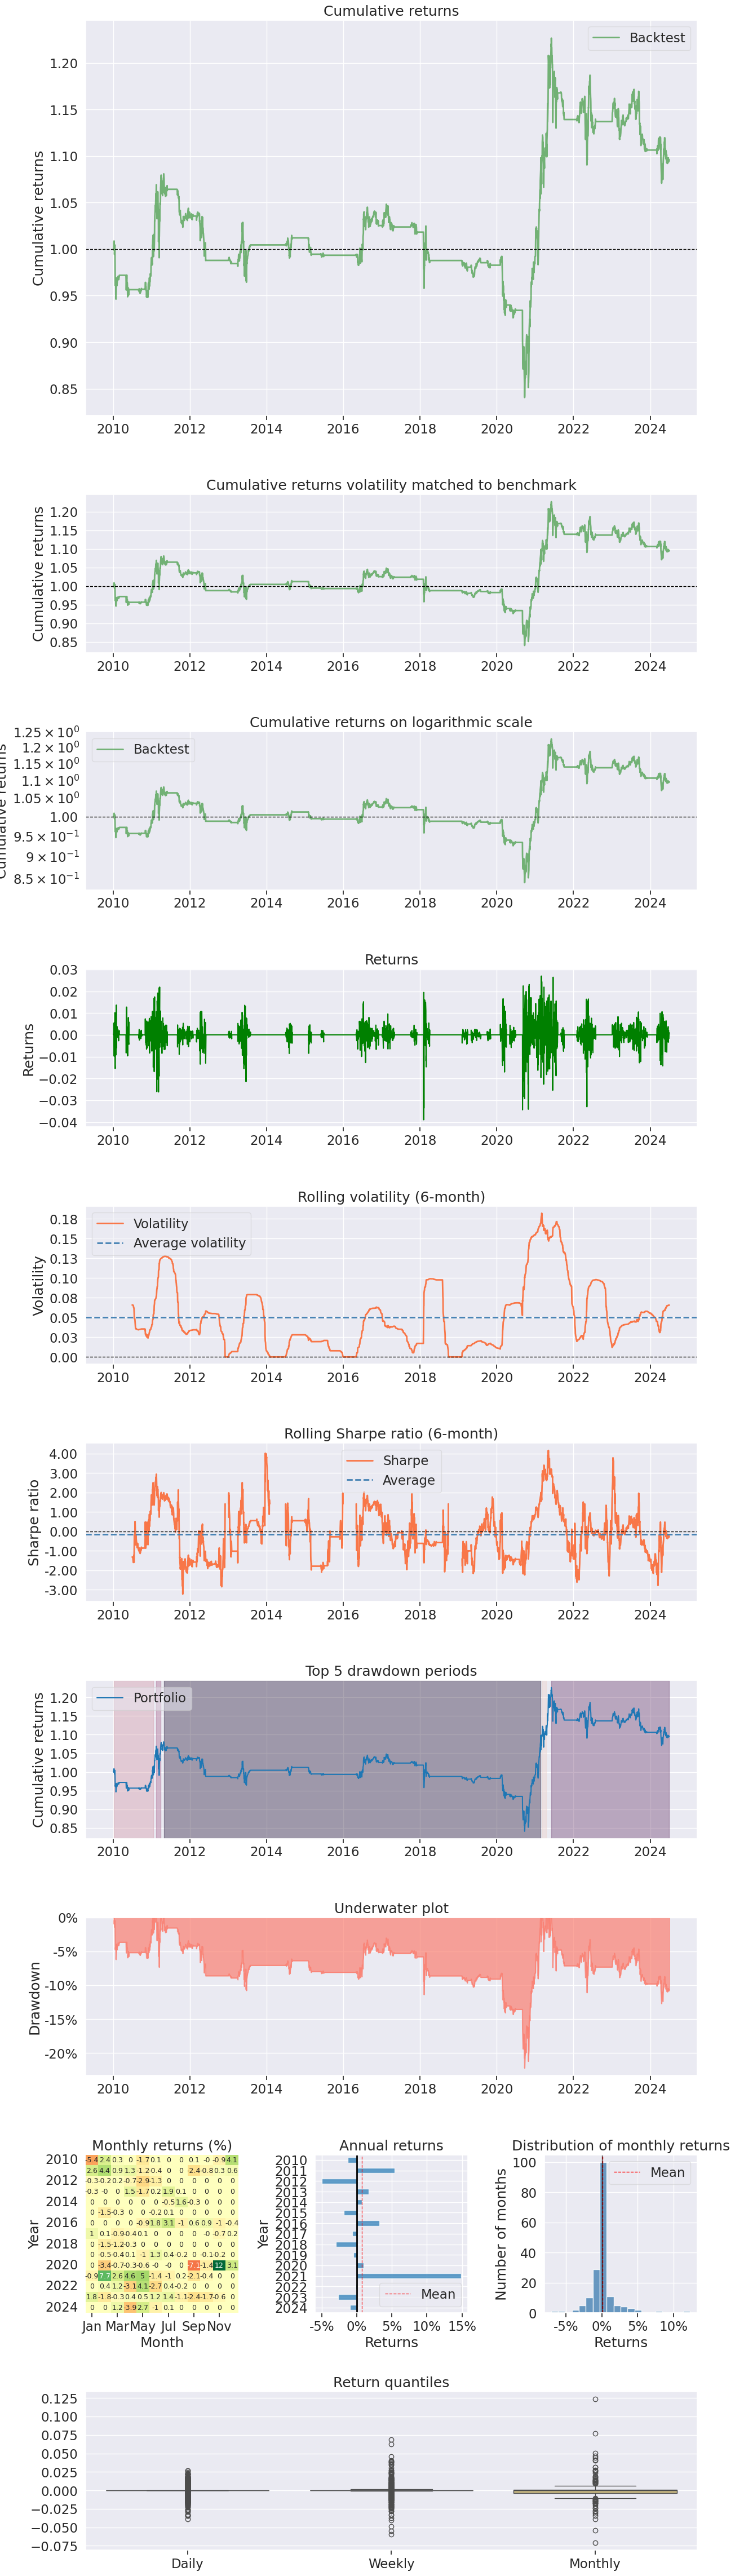

In [9]:
perf = zipline.run_algorithm(
    start=start_date, end=end_date, 
    initialize=initialize, 
    analyze=analyze, 
    capital_base=intial_portfolio,  
    data_frequency = 'daily', 
    bundle='us_etfs' ) 

In [ ]:
data = perf['portfolio_value'].copy()
data.index = data.index.date

data.to_csv('systematic_momentum.csv')

In [15]:
perf['portfolio_value']

2020-01-02 00:00:00+00:00    1.000000e+07
2020-01-03 00:00:00+00:00    1.000000e+07
2020-01-06 00:00:00+00:00    1.000000e+07
2020-01-07 00:00:00+00:00    1.000000e+07
2020-01-08 00:00:00+00:00    1.000000e+07
                                 ...     
2024-06-25 00:00:00+00:00    9.896164e+06
2024-06-26 00:00:00+00:00    9.878704e+06
2024-06-27 00:00:00+00:00    9.899956e+06
2024-06-28 00:00:00+00:00    9.900132e+06
2024-07-01 00:00:00+00:00    9.905070e+06
Name: portfolio_value, Length: 1131, dtype: float64

In [17]:
perf.portfolio_value.to_csv('125d version.csv')